In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Parameters
w = 2 * np.pi
time = 0
p = np.zeros(50)
t = np.zeros(50)

# Generate data
for i in range(50):
    p[i] = (np.exp(-time)) * np.sin(w * time)
    time += 0.1
    if p[i] > 0.0:
        t[i] = 1
    elif p[i] < 0.0:
        t[i] = -1

# Create and train the first neural network
model1 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='tanh', input_shape=(1,)),
    tf.keras.layers.Dense(1, activation='linear')
])

model1.compile(optimizer='adam', loss='mse')
history1 = model1.fit(p, t, epochs=10000, verbose=0)

# Calculate the gradient of p
dp = np.gradient(p)

# Create and train the second neural network (net1)
model2_dp = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='tanh', input_shape=(1,)),
    tf.keras.layers.Dense(1, activation='relu')
])

model2_p = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='tanh', input_shape=(1,)),
    tf.keras.layers.Dense(1, activation='relu')
])

model2_dp.compile(optimizer='adam', loss='mse')
model2_p.compile(optimizer='adam', loss='mse')

history2_dp = model2_dp.fit(dp, tprop, epochs=10000, verbose=0)
history2_p = model2_p.fit(p, tint, epochs=10000, verbose=0)

# Calculate tprop and tint
tprop = 10.0 * np.abs(dp)
tint = np.exp(-np.abs(p))


# Create subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

# Plot the generated data
axs[0, 0].plot(p, t, 'o')
axs[0, 0].set_title('Generated Data')

# Original vs Predicted Data
axs[0, 1].plot(p, t, 'o', label='Original Data')
axs[0, 1].plot(p, model1.predict(p), '*', label='Predicted Data')
axs[0, 1].set_title('Original vs Predicted Data')
axs[0, 1].legend()

# Gradient of p
axs[0, 2].plot(dp, '*')
axs[0, 2].set_title('Gradient of p')

# tprop vs dp
axs[1, 0].plot(dp, tprop, 'o', label='tprop')
axs[1, 0].set_title('tprop vs dp')
axs[1, 0].legend()

# tint vs p
axs[1, 1].plot(p, tint, 'o', label='tint')
axs[1, 1].set_title('tint vs p')
axs[1, 1].legend()

# tprop vs dp - Predicted by net1
axs[1, 2].plot(dp, tprop, 'o', label='tprop')
axs[1, 2].plot(dp, model2_dp.predict(dp), '*', label='Predicted tprop')
axs[1, 2].set_title('tprop vs dp - Predicted by net1')
axs[1, 2].legend()

# tint vs p - Predicted by net2
axs[2, 0].plot(p, tint, 'o', label='tint')
axs[2, 0].plot(p, model2_p.predict(p), '*', label='Predicted tint')
axs[2, 0].set_title('tint vs p - Predicted by net2')
axs[2, 0].legend()

# Adjust layout to prevent clipping of titles
plt.tight_layout()

# Show the plots
plt.show()


NameError: name 'tprop' is not defined

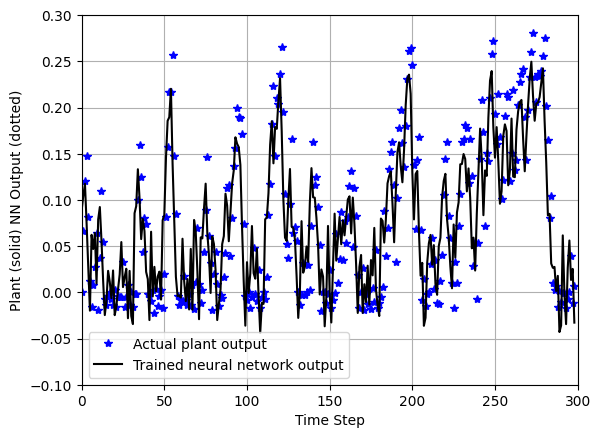

In [8]:
import numpy as np
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

# Initialize variables
yp = np.zeros(302)
yp[1] = 0
yp[2] = 0
u = np.random.uniform(-2, 2, size=301)
out = np.zeros(300)
in_data = np.zeros(300)

# Generate data
for k in range(2, 302):
    yp[k] = yp[k - 1] * (yp[k - 2] + 2) * (yp[k - 1] + 2.5) / (8.5 + yp[k - 1]**2 + yp[k - 2]**2) + u[k - 1]
    out[k - 2] = (yp[k] - u[k - 1]) / 20
    in_data[k - 2] = yp[k] / 20

# Prepare training data
plantin = np.vstack((in_data[:-1], in_data[1:])).T
plantout = out[:-1]

# Create and train the neural network
nn_input_range = (np.min(in_data), np.max(in_data))
nn = MLPRegressor(hidden_layer_sizes=(10,), activation='logistic', solver='lbfgs', max_iter=500)
nn.fit(plantin, plantout)

# Generate neural network output
trained_out = nn.predict(plantin)

# Plot the results
plt.plot(plantout, '*b', label='Actual plant output')
plt.plot(trained_out, '-k', label='Trained neural network output')
plt.grid()
plt.axis([0, 300, -0.1, 0.3])
plt.xlabel('Time Step')
plt.ylabel('Plant (solid) NN Output (dotted)')
plt.legend()
plt.show()


In [12]:
import numpy as np

# Initialization
v = np.array([[0.197, 0.3191, -0.1448, 0.3394], [0.3099, 0.1904, -0.0347, -0.4861]])
v1 = np.zeros((2, 4))
b1 = np.array([-0.3378, 0.2771, 0.2859, -0.3329])
b2 = -0.1401
w = np.array([0.4919, -0.2913, -0.3979, 0.3581])
e = 0
n = 0.5
w1 = np.zeros(4)
b11 = np.zeros(4)
b22 = 0
deltav = np.zeros((2, 4))
t = np.array([-1, 1, 1, -1])
x = np.array([[1, 1, -1, -1], [1, -1, 1, -1]])

# Training
for i in range(4):
    for j in range(4):
        net = b1[j] + x[0, j] * v[0, j] + x[1, j] * v[1, j]
        zinj = (2 / (1 + np.exp(-(n * net)))) - 1
        zj = (1 / 2) * (1 - (zinj * zinj))
        net1 = b2 + np.sum(zj * w)  # Corrected line
        yink = (2 / (1 + np.exp(-(n * net1)))) - 1
        yk = (1 / 2) * (1 - (yink * yink))

        # Delta Rule Updates
        deltaw = n * (t[i] - yk) * yk * zj  # Corrected line
        w1 = w.copy()
        v1 = v.copy()

        # for hidden unit
        deltainj = n * (t[i] - yk) * yk * w
        deltav = deltainj * zj
        delb2 = n * (t[i] - yk) * yk
        delb1 = n * deltav

        for ii in range(2):
            deltav = n * deltav * x[ii, j]

        if yk - t[i] != 0:
            w = w + deltaw
            b1 = b1 + delb1
            v = v + deltav
            b2 = b2 + delb2

# Print the final weights and biases
print("Final weights (v):", v)
print("Final bias (b1):", b1)
print("Final weight (w):", w)
print("Final bias (b2):", b2)


Final weights (v): [[ 0.18809571  0.30810952 -0.15607443  0.33013931]
 [ 0.30099571  0.17940952 -0.04597443 -0.49536069]]
Final bias (b1): [-0.43658963  0.47253584  0.52138236 -0.38142486]
Final weight (w): [-0.25944184 -1.04264184 -1.14924184 -0.39324184]
Final bias (b2): -1.6536090375001633


In [19]:
import numpy as np

# Initialization
v = np.array([[0.197, 0.3191, -0.1448, 0.3394], [0.3099, 0.1904, -0.0347, -0.4861]])
v1 = np.zeros((2, 4))
b1 = np.array([-0.3378, 0.2771, 0.2859, -0.3329])
b2 = -0.1401
w = np.array([0.4919, -0.2913, -0.3979, 0.3581])
e = 0
n = 0.5
w1 = np.zeros((4, 1))
b11 = np.zeros((4, 1))
b22 = 0
deltav = np.zeros((2, 4))
t = np.array([-1, 1, 1, -1])
x = np.array([[1, 1, -1, -1], [1, -1, 1, -1]])

# Training
for i in range(4):
    for j in range(4):
        net = b1[j] + x[0, j] * v[0, j] + x[1, j] * v[1, j]
        
        # Hidden layer
        zinj = (2 / (1 + np.exp(-(n * net)))) - 1
        zj = (1 / 2) * (1 - (zinj * zinj))
        
        # Output layer
        net1 = b2 + np.sum(zj * w)  # Corrected line
        yink = (2 / (1 + np.exp(-(n * net1)))) - 1
        yk = (1 / 2) * (1 - (yink * yink))
        
        # Delta rule updates
        deltaw = n * (t[i] - yk) * yk * zj
        w1 = w.copy()
        v1 = v.copy()
        # for hidden unit
        deltainj = n * (t[i] - yk) * yk * w
        deltav = deltainj * zj
        delb2 = n * (t[i] - yk) * yk
        delb1 = n * deltainj

        for ii in range(2):
            deltav[ii] = n * deltainj[ii] * x[ii, j]  # Corrected line

        if yk - t[i] != 0:
            w = w + deltaw
            b1 = b1 + delb1
            v = v + deltav
            b2 = b2 + delb2
        else:
            break

# Print the final weights and biases
print("Final weights (v):", v)
print("Final bias (b1):", b1)
print("Final weight (w):", w)
print("Final bias (b2):", b2)


Final weights (v): [[-0.057011    0.25932241  0.32574708  0.24252819]
 [ 0.055889    0.13062241  0.43584708 -0.58297181]]
Final bias (b1): [-0.53687074  0.67091566  0.7604124  -0.43068346]
Final weight (w): [-0.25865409 -1.04185409 -1.14845409 -0.39245409]
Final bias (b2): -1.654110209530684
